<a href="https://colab.research.google.com/github/aindaorlando-coder/provaTesi1/blob/main/PrototipoPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
#Collegamento e clonazione repo GitHub, da fare ogni volta che si apre colab
!git clone https://github.com/aindaorlando-coder/provaTesi1.git
%cd provaTesi1

!git config --global user.name "aindaorlando-coder"
!git config --global user.email "ainda.orlando@gmail.com"

Cloning into 'provaTesi1'...
remote: Enumerating objects: 11817, done.
remote: Total 11817 (delta 0), reused 0 (delta 0), pack-reused 11817 (from 2)
Receiving objects: 100% (11817/11817), 7.95 MiB | 10.38 MiB/s, done.
Resolving deltas: 100% (7168/7168), done.
/content/provaTesi1/provaTesi1


In [4]:
#creo il dataset, se voglio aumentare il numero di osservazioni devo cambiare il terzo parametro nella np.random. Ora ho
#un dataset contenente 100 osservazioni
import pandas as pd
import numpy as np

np.random.seed(42)
data = pd.DataFrame({
    "PM2.5": np.random.randint(5, 100, 100),
    "NO2": np.random.randint(10, 80, 100),
    "Temperatura": np.random.randint(10, 35, 100),
    "Umidità": np.random.randint(20, 90, 100),
    "IndiceQualità": np.random.choice(["Buono", "Cattivo"], 100)
})

data.to_csv("dataset_simulato.csv", index=False)
print("Dataset simulato creato!")

Dataset simulato creato!


In [5]:
#carico nella variabile data il dataset
import pandas as pd

data = pd.read_csv("dataset_simulato.csv")
data.head()

,PM2.5,NO2,Temperatura,Umidità,IndiceQualità
0,56,69,20,52,Cattivo
1,97,50,33,67,Cattivo
2,19,38,26,78,Buono
3,76,24,15,41,Cattivo
4,65,54,33,49,Cattivo


In [7]:
#Effettuo il controllo di completezza dei dati
print(data.info())
print("\nValori mancanti:")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PM2.5          100 non-null    int64 
 1   NO2            100 non-null    int64 
 2   Temperatura    100 non-null    int64 
 3   Umidità        100 non-null    int64 
 4   IndiceQualità  100 non-null    object
dtypes: int64(4), object(1)
memory usage: 4.0+ KB
None

Valori mancanti:
PM2.5            0
NO2              0
Temperatura      0
Umidità          0
IndiceQualità    0
dtype: int64


In [8]:
#Fase di preprocessing, serve a “È stata effettuata una fase di preprocessing per rendere i dati utilizzabili dai modelli statistici,
#includendo encoding delle variabili categoriche e normalizzazione delle variabili numeriche
#nel caso specifico ho trasformato il valore buono/cattivo e ho riportato tutti i sati in scala.
from sklearn.preprocessing import StandardScaler

# Encoding variabile target
data["IndiceQualità"] = data["IndiceQualità"].map({"Buono": 0, "Cattivo": 1})

# Normalizzazione variabili numeriche
scaler = StandardScaler()
numerical_cols = ["PM2.5", "NO2", "Temperatura", "Umidità"]

data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

data.head()

,PM2.5,NO2,Temperatura,Umidità,IndiceQualità
0,0.045468,1.218121,-0.200911,-0.308402,1
1,1.468518,0.323828,1.462681,0.475671,1
2,-1.238748,-0.240988,0.566901,1.050658,0
3,0.739639,-0.899941,-0.840754,-0.883389,1
4,0.357845,0.512100,1.462681,-0.465217,1


In [9]:
#statistiche descrittive
#count → numero di osservazioni
#mean → media
#std → deviazione standard
#min → valore minimo
#25% → primo quartile
#50% → mediana
#75% → terzo quartile
#max → valore massimo
data.describe()

,PM2.5,NO2,Temperatura,Umidità,IndiceQualità
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100.00
mean,6.883383e-17,1.176836e-16,-6.217249e-17,1.873501e-17,0.55
std,1.005038e+00,1.005038e+00,1.005038e+00,1.005038e+00,0.50
min,-1.689959e+00,-1.558894e+00,-1.480597e+00,-1.928820e+00,0.00
25%,-9.437253e-01,-9.587761e-01,-9.687224e-01,-7.788461e-01,0.00
50%,9.753101e-02,1.788586e-02,5.502650e-02,1.097703e-01,1.00
75%,8.524418e-01,8.533436e-01,9.508068e-01,8.677078e-01,1.00
max,1.537936e+00,1.688801e+00,1.590650e+00,1.625645e+00,1.00


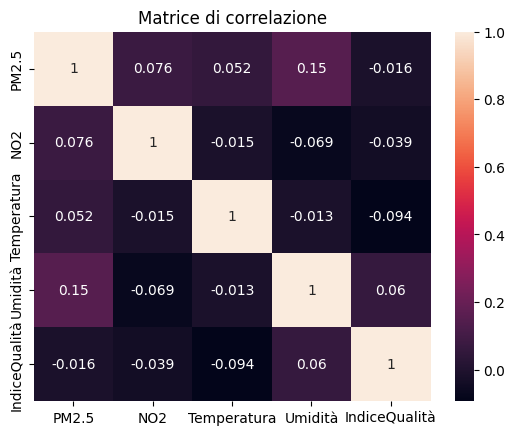

In [16]:
#Correlazioni
#crea la matrice di correlazione
corr = data.select_dtypes(include='number').corr()
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True)
plt.title("Matrice di correlazione")
plt.show()

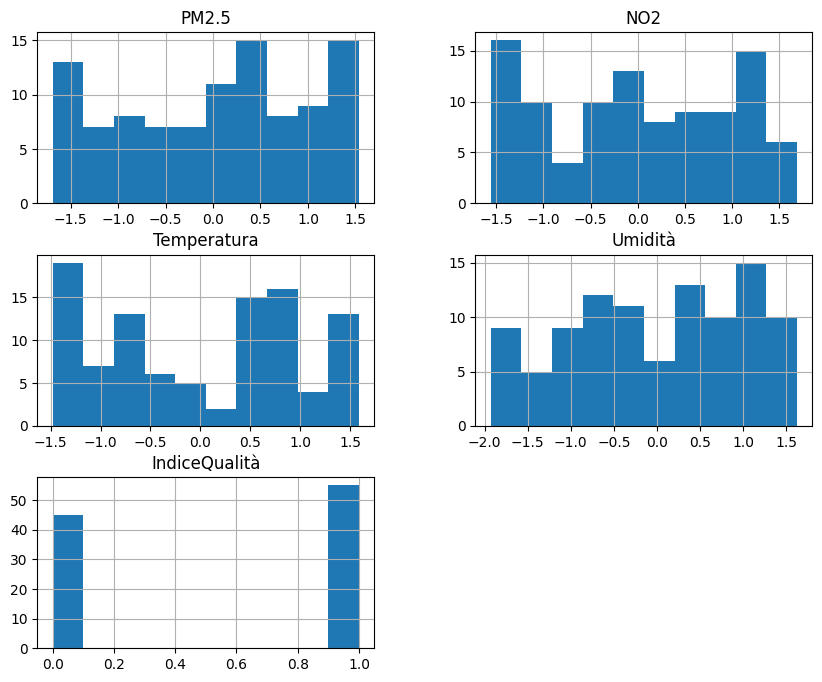

In [17]:
#distribuzione variabili
#per studiare la forma delle distribuzioni, la presenza di asimmetrie e possibili outlier.
data.hist(figsize=(10,8))
plt.show()

In [40]:
#controllo se ci sono modifiche
!git status


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	provaTesi1/

nothing added to commit but untracked files present (use "git add" to track)


In [36]:
#salvataggio
!git add .
!git commit -m
!git push


error: switch `m' requires a value
fatal: could not read Username for 'https://github.com': No such device or address


In [38]:
#posizionamento nella repo
%cd /content/provaTesi1

/content/provaTesi1


In [37]:
#visualizzazione contenuto repo
!ls /content

dataset_simulato.csv  provaTesi1  sample_data


In [52]:
!ls



agents		      get-shit-done	 README.ko-KR.md  STATE.md
assets		      hooks		 README.md	  tests
bin		      LICENSE		 README.pt-BR.md  tsconfig.json
CHANGELOG.md	      package.json	 README.zh-CN.md  VERSIONING.md
commands	      package-lock.json  ROADMAP.md	  vitest.config.ts
CONTRIBUTING.md       PROJECT.md	 scripts
dataset_simulato.csv  provaTesi1	 sdk
docs		      README.ja-JP.md	 SECURITY.md
